In [57]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing import Any
import requests
import math
import os

In [58]:
load_dotenv()

True

In [59]:
llm = ChatOpenAI(
    model="openai/gpt-oss-20b",
    base_url="https://api.groq.com/openai/v1",
    temperature=0,
    api_key=os.getenv('GROQ_API_KEY')
)



In [60]:
search_tool = TavilySearch(
    max_results=5,
    topic="general",
    search_depth="advanced"
)

@tool
def calculator(expression: str) -> str:
    """
    Useful for simple math calculations.
    Input should be a valid math expression.
    Example: 2 + 2, math.sqrt(16), 10 * 5
    """

    try:
        allowed = {
            "math": math,
            "abs": abs,
            "round": round,
            "min": min,
            "max": max,
            "sum": sum
        }

        result = eval(expression, {"__builtins__": {}}, allowed)
        return str(result)

    except Exception as e:
        return f"Calculation error: {str(e)}"


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={os.getenv('ALPHA_VANTAGE_KEY')}"
    r = requests.get(url)
    return r.json()


@tool
def get_current_weather(location: str) -> str:
    """
    Get the current real-time weather for a given city or location.

    Args:
        location: City or location name, for example:
                  "Dhaka", "London, UK", or "New York, US".

    Returns:
        A formatted current weather report.
    """

    api_key = os.getenv("OPENWEATHER_API_KEY")

    if not api_key:
        return (
            "Weather API key is missing. "
            "Set the OPENWEATHER_API_KEY environment variable."
        )

    try:
        # Step 1: Convert the location name into latitude and longitude
        geocoding_url = "https://api.openweathermap.org/geo/1.0/direct"

        geocoding_params = {
            "q": location,
            "limit": 1,
            "appid": api_key,
        }

        geo_response = requests.get(
            geocoding_url,
            params=geocoding_params,
            timeout=10,
        )
        geo_response.raise_for_status()

        locations: list[dict[str, Any]] = geo_response.json()

        if not locations:
            return f"Could not find the location: {location}"

        latitude = locations[0]["lat"]
        longitude = locations[0]["lon"]
        resolved_name = locations[0].get("name", location)
        country = locations[0].get("country", "")
        state = locations[0].get("state", "")

        # Step 2: Get current weather using latitude and longitude
        weather_url = "https://api.openweathermap.org/data/2.5/weather"

        weather_params = {
            "lat": latitude,
            "lon": longitude,
            "appid": api_key,
            "units": "metric",
        }

        weather_response = requests.get(
            weather_url,
            params=weather_params,
            timeout=10,
        )
        weather_response.raise_for_status()

        weather_data = weather_response.json()

        temperature = weather_data["main"]["temp"]
        feels_like = weather_data["main"]["feels_like"]
        humidity = weather_data["main"]["humidity"]
        pressure = weather_data["main"]["pressure"]
        description = weather_data["weather"][0]["description"]
        wind_speed = weather_data.get("wind", {}).get("speed", "N/A")
        visibility_meters = weather_data.get("visibility")

        visibility_km = (
            round(visibility_meters / 1000, 1)
            if visibility_meters is not None
            else "N/A"
        )

        location_parts = [resolved_name]

        if state:
            location_parts.append(state)

        if country:
            location_parts.append(country)

        display_location = ", ".join(location_parts)

        return (
            f"Current weather in {display_location}:\n"
            f"- Condition: {description.title()}\n"
            f"- Temperature: {temperature}°C\n"
            f"- Feels like: {feels_like}°C\n"
            f"- Humidity: {humidity}%\n"
            f"- Pressure: {pressure} hPa\n"
            f"- Wind speed: {wind_speed} m/s\n"
            f"- Visibility: {visibility_km} km"
        )

    except requests.Timeout:
        return "The weather service request timed out. Please try again."

    except requests.HTTPError as error:
        status_code = error.response.status_code if error.response else "unknown"

        if status_code == 401:
            return "The OpenWeather API key is invalid or inactive."

        return f"Weather API returned an HTTP error: {status_code}"

    except requests.RequestException as error:
        return f"Could not connect to the weather service: {error}"

    except (KeyError, TypeError, ValueError) as error:
        return f"Unexpected weather API response: {error}"



In [61]:
# Make tool list
tools = [search_tool,calculator, get_stock_price,get_current_weather]

# Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [62]:
# state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [63]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

In [64]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [65]:

graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")    



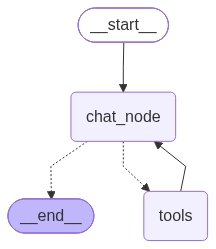

In [66]:
chatbot = graph.compile()

chatbot

In [67]:


# Regular chat
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!")]})

print(out["messages"][-1].content)



Hello! How can I help you today?


In [71]:


# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 8989898*90909090+5404040?")]})
print(out["messages"][-1].content)



In [79]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="what are the new movie releases in 2026")]})
print(out["messages"])

[HumanMessage(content='what are the new movie releases in 2026', additional_kwargs={}, response_metadata={}, id='92d78a86-8562-4433-a03a-6a740ab0d9ec'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 492, 'total_tokens': 581, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 51, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.095148496, 'prompt_time': 0.025027847, 'completion_time': 0.09008079, 'total_time': 0.115108637}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e594c51153', 'id': 'chatcmpl-63197ee6-bcb4-442b-92f0-244318fde540', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0bacc-9f9f-73d0-a5d8-43a94090c277-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '2026 new movie releases 2026', 'search_depth

In [75]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="First find out the stock price of Apple using get stock price tool then use the calculator tool to find out how much will it take to purchase 50 shares?")]})
print(out["messages"][-1].content)

**Apple (AAPL) – Current Price (as of 2026‑09‑18)**  
- **Price per share:** **$336.13**

**Cost to purchase 50 shares**  
- Calculation: 336.13 × 50 = **$16,806.50**

So, buying 50 shares of Apple would cost you **$16,806.50** at the current market price.


In [77]:


# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the current weather in Quito?")]})
print(out["messages"][-1].content)



**Current weather in Quito, Ecuador**

- **Condition:** Moderate rain  
- **Temperature:** 21.4 °C (≈70 °F)  
- **Feels like:** 20.3 °C  
- **Humidity:** 29 %  
- **Pressure:** 1013 hPa  
- **Wind:** 2.1 m/s (≈7.5 km/h)  
- **Visibility:** 10 km  

Enjoy your day!
